# MIT Incidentalità stradale mensile 2001-2018 — v0

**Domanda guida:** come cambia nel tempo il profilo mensile dell'incidentalità stradale in Italia tra 2001 e 2018?

**Fonte:** MIT — portale open data, dataset mensile 2001-2018  
**Issue:** dataciviclab/dataset-incubator#34  
**Perimetro:** solo righe mensili (216 su 288 totali); righe trimestrali escluse per anomalie nella fonte

---

### Nota metodologica — qualità dei dati

L'ispezione del mart ha rilevato **19 righe mensili su 216** con valori anomali in `incidenti` o `feriti` (trailing zero mancante nella fonte MIT). Queste righe non sono state corrette: modificare la fonte non è difendibile senza documentazione ufficiale.

Conseguenze pratiche:
- **`morti`**: campo pulito, nessuna anomalia rilevata. Usato come metrica principale per il trend e la stagionalità.
- **`incidenti` e `feriti`**: presentano valori anomali in anni sparsi. I trend di lungo periodo restano leggibili ma i totali annuali di questi campi sono sottostimati per gli anni coinvolti.
- **Indici derivati** (`indice_mortalita`, `indice_gravita`, `indice_lesivita`): calcolati dalla fonte MIT sull'intera serie originale, inclusi i trimestrali. Sono orientativi e non ricalcolabili esattamente dal solo mensile filtrato.

In [1]:
from pathlib import Path
import subprocess, json
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.1f}'.format)

# Path al mart — usa inspect paths se disponibile, altrimenti path relativo
MART = Path("../../../out/data/mart/mit_incidentalita_mensile/2001/mart_mensile.parquet")
assert MART.exists(), f"Mart non trovato: {MART}. Eseguire: toolkit run all --config dataset.yml"

con = duckdb.connect()
df = con.execute(f"SELECT * FROM '{MART}' ORDER BY anno, mese_num").fetchdf()
print(f"Righe caricate: {len(df)}  |  Anni: {df.anno.min()}–{df.anno.max()}")
df.head(3)

Righe caricate: 216  |  Anni: 2001–2018


,anno,mese,mese_num,incidenti,morti,feriti,incidenti_mortali,indice_mortalita,indice_gravita,indice_lesivita
0,2001,Gennaio,1,19332,516,27874,470,2.7,1.8,144.2
1,2001,Febbraio,2,17908,474,2524,428,2.6,1.8,140.9
2,2001,Marzo,3,2092,551,2991,488,2.6,1.8,143.0


## Righe anomale nel mart

Righe con valori chiaramente sottostimati rispetto alla mediana annuale del campo (< 30% della mediana). Queste righe sono incluse nel mart così come sono nella fonte: la nota metodologica sopra spiega perché.

In [2]:
import numpy as np

anomalie = []
for anno, grp in df.groupby('anno'):
    med_inc = grp['incidenti'].median()
    med_fer = grp['feriti'].median()
    for _, row in grp.iterrows():
        flags = []
        if row['incidenti'] < med_inc * 0.3:
            flags.append(f"incidenti={row['incidenti']:,} (mediana={med_inc:,.0f})")
        if row['feriti'] < med_fer * 0.3:
            flags.append(f"feriti={row['feriti']:,} (mediana={med_fer:,.0f})")
        if flags:
            anomalie.append({'anno': anno, 'mese': row['mese'], 'anomalie': ', '.join(flags)})

df_anom = pd.DataFrame(anomalie)
print(f"Righe anomale: {len(df_anom)} su {len(df)}")
df_anom

Righe anomale: 19 su 216


,anno,mese,anomalie
0,2001,Febbraio,"feriti=2,524 (mediana=30,350)"
1,2001,Marzo,"incidenti=2,092 (mediana=21,740), feriti=2,991..."
2,2001,Maggio,"feriti=3,363 (mediana=30,350)"
3,2003,Settembre,"feriti=2,844 (mediana=29,222)"
4,2004,Agosto,"incidenti=1,824 (mediana=20,102)"
5,2004,Dicembre,"feriti=2,782 (mediana=28,127)"
6,2006,Marzo,"incidenti=1,812 (mediana=19,786)"
7,2006,Dicembre,"feriti=2,723 (mediana=27,664)"
8,2008,Gennaio,"feriti=2,374 (mediana=25,588)"
9,2009,Agosto,"incidenti=1,701 (mediana=17,536)"


## 1. Trend di lungo periodo — morti per anno

`morti` è il campo più affidabile: nessuna anomalia rilevata. Il trend mostra la traiettoria reale dell'incidentalità letale in Italia.

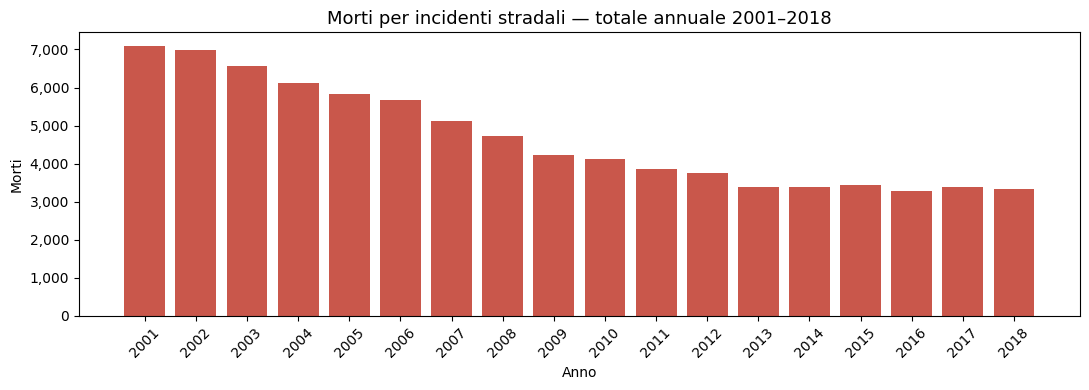

Morti 2001: 7,096  |  Morti 2018: 3,334  |  Variazione: -53.0%


In [3]:
annuali = df.groupby('anno').agg(
    morti=('morti', 'sum'),
    incidenti=('incidenti', 'sum'),
    feriti=('feriti', 'sum'),
    incidenti_mortali=('incidenti_mortali', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(annuali.anno, annuali.morti, color='#c0392b', alpha=0.85)
ax.set_title('Morti per incidenti stradali — totale annuale 2001–2018', fontsize=13)
ax.set_xlabel('Anno')
ax.set_ylabel('Morti')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(annuali.anno)
ax.set_xticklabels(annuali.anno, rotation=45)
plt.tight_layout()
plt.show()

calo = (annuali.iloc[-1]['morti'] - annuali.iloc[0]['morti']) / annuali.iloc[0]['morti'] * 100
print(f"Morti 2001: {annuali.iloc[0]['morti']:,}  |  Morti 2018: {annuali.iloc[-1]['morti']:,}  |  Variazione: {calo:.1f}%")

## 2. Trend incidenti e feriti — con segnalazione anomalie

I totali annuali di `incidenti` e `feriti` sono sottostimati per gli anni con righe anomale. Il trend di lungo periodo resta leggibile ma i valori assoluti di quegli anni non sono comparabili.

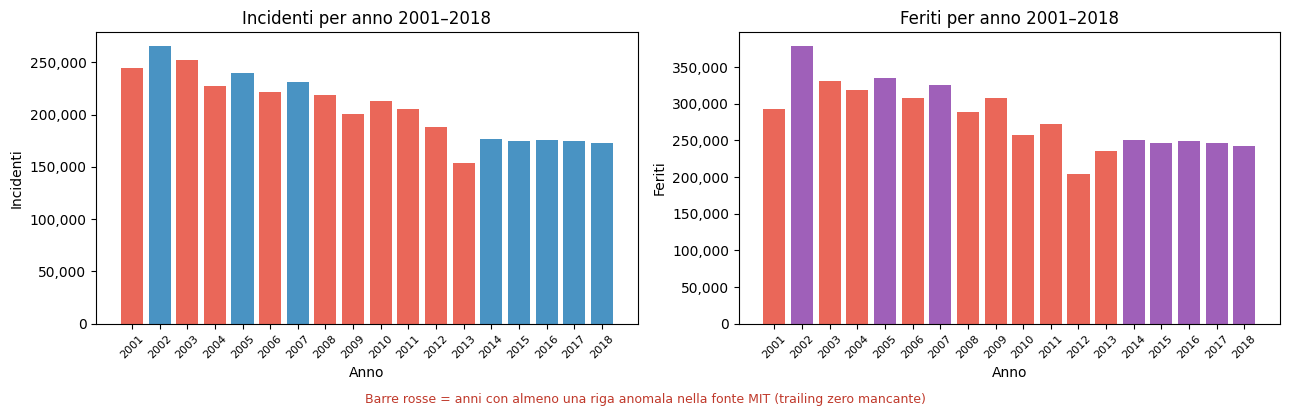

In [4]:
anni_anomali = set(df_anom['anno'].tolist()) if len(df_anom) > 0 else set()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, colore, label in [
    (axes[0], 'incidenti', '#2980b9', 'Incidenti'),
    (axes[1], 'feriti', '#8e44ad', 'Feriti'),
]:
    colors = ['#e74c3c' if a in anni_anomali else colore for a in annuali.anno]
    ax.bar(annuali.anno, annuali[col], color=colors, alpha=0.85)
    ax.set_title(f'{label} per anno 2001–2018', fontsize=12)
    ax.set_xlabel('Anno')
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xticks(annuali.anno)
    ax.set_xticklabels(annuali.anno, rotation=45, fontsize=8)

fig.text(0.5, -0.02, 'Barre rosse = anni con almeno una riga anomala nella fonte MIT (trailing zero mancante)',
         ha='center', fontsize=9, color='#c0392b')
plt.tight_layout()
plt.show()

## 3. Stagionalità — morti per mese

Media mensile su tutti gli anni disponibili. Agosto e luglio mostrano i picchi di mortalità.

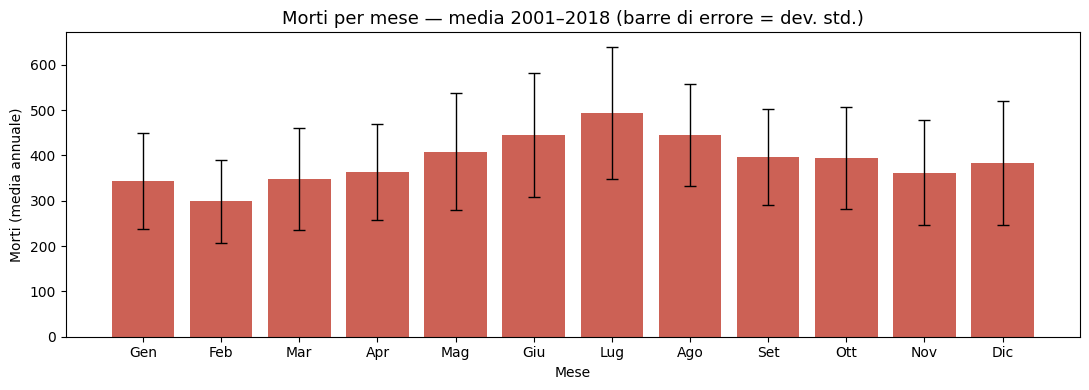

Media morti per mese:
     mese  morti_media  morti_std
  Gennaio        343.1      105.8
 Febbraio        298.3       91.8
    Marzo        347.9      111.9
   Aprile        363.0      105.7
   Maggio        408.0      129.0
   Giugno        445.2      135.9
   Luglio        493.5      145.9
   Agosto        445.5      112.9
Settembre        396.7      105.2
  Ottobre        394.4      113.2
 Novembre        362.2      115.3
 Dicembre        383.3      136.1


In [5]:
mesi_ord = ['Gennaio','Febbraio','Marzo','Aprile','Maggio','Giugno',
            'Luglio','Agosto','Settembre','Ottobre','Novembre','Dicembre']

stagionale = df.groupby('mese_num').agg(
    mese=('mese', 'first'),
    morti_media=('morti', 'mean'),
    morti_std=('morti', 'std'),
).reset_index().sort_values('mese_num')

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(stagionale.mese_num, stagionale.morti_media, color='#c0392b', alpha=0.8,
       yerr=stagionale.morti_std, capsize=4, error_kw={'linewidth': 1})
ax.set_title('Morti per mese — media 2001–2018 (barre di errore = dev. std.)', fontsize=13)
ax.set_xlabel('Mese')
ax.set_ylabel('Morti (media annuale)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([m[:3] for m in mesi_ord])
plt.tight_layout()
plt.show()

print("Media morti per mese:")
print(stagionale[['mese','morti_media','morti_std']].to_string(index=False))

## 4. Heatmap stagionalità — morti per anno e mese

Vista completa: ogni cella è il numero di morti in quel mese/anno. Il gradiente di colore mostra sia il calo strutturale (anni recenti più chiari) sia la stagionalità (estate più scura).

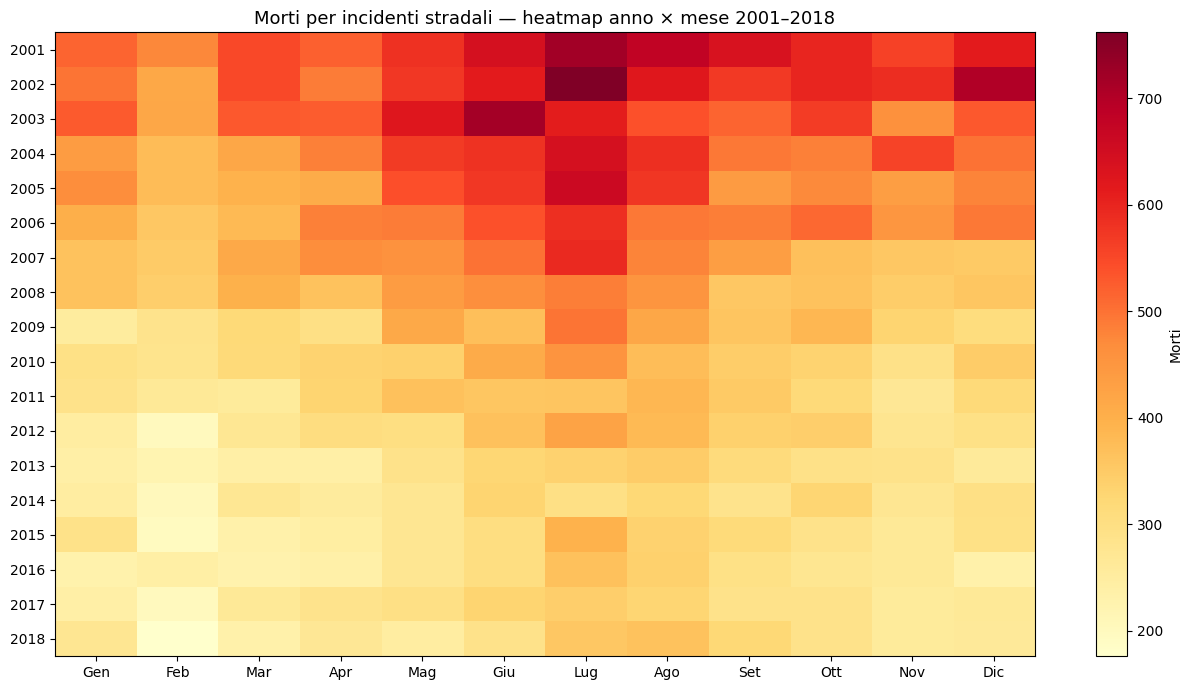

In [6]:
pivot = df.pivot(index='anno', columns='mese_num', values='morti')
pivot.columns = [m[:3] for m in mesi_ord]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Morti')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns)
ax.set_title('Morti per incidenti stradali — heatmap anno × mese 2001–2018', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Rapporto morti / incidenti — indice di mortalità ricalcolato

Ricalcolo dell'indice come `morti / incidenti * 100`. Diversamente dall'`indice_mortalita` MIT (calcolato sulla serie completa con i trimestrali), questo è ricalcolabile dal solo mensile e confrontabile anno per anno.

Gli anni con righe anomale in `incidenti` producono un indice sovrastimato (denominatore artificialmente basso).

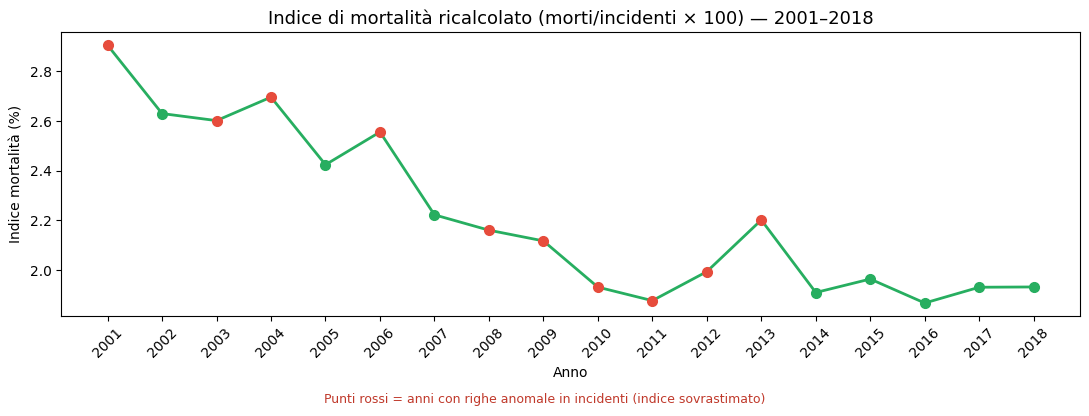

Indice mortalità ricalcolato per anno:
 anno  morti  incidenti  mortalita_calc
 2001   7096     244272             2.9
 2002   6980     265402             2.6
 2003   6563     252271             2.6
 2004   6122     227074             2.7
 2005   5818     240011             2.4
 2006   5669     221816             2.6
 2007   5131     230871             2.2
 2008   4731     218963             2.2
 2009   4237     200096             2.1
 2010   4114     212997             1.9
 2011   3860     205638             1.9
 2012   3753     188228             2.0
 2013   3385     153741             2.2
 2014   3381     177031             1.9
 2015   3428     174539             2.0
 2016   3283     175791             1.9
 2017   3378     174933             1.9
 2018   3334     172553             1.9


In [7]:
annuali['mortalita_calc'] = annuali['morti'] / annuali['incidenti'] * 100

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#e74c3c' if a in anni_anomali else '#27ae60' for a in annuali.anno]
ax.plot(annuali.anno, annuali.mortalita_calc, marker='o', color='#27ae60', linewidth=2)
for a, v, c in zip(annuali.anno, annuali.mortalita_calc, colors):
    ax.plot(a, v, 'o', color=c, markersize=7)
ax.set_title('Indice di mortalità ricalcolato (morti/incidenti × 100) — 2001–2018', fontsize=13)
ax.set_xlabel('Anno')
ax.set_ylabel('Indice mortalità (%)')
ax.set_xticks(annuali.anno)
ax.set_xticklabels(annuali.anno, rotation=45)
fig.text(0.5, -0.02, 'Punti rossi = anni con righe anomale in incidenti (indice sovrastimato)',
         ha='center', fontsize=9, color='#c0392b')
plt.tight_layout()
plt.show()

print("Indice mortalità ricalcolato per anno:")
print(annuali[['anno','morti','incidenti','mortalita_calc']].to_string(index=False))

## Lettura sintetica

**Trend strutturale:** il numero di morti per incidenti stradali in Italia è calato in modo consistente da 7.096 nel 2001 a 3.334 nel 2018, una riduzione di circa il 53% in 17 anni.

**Stagionalità:** i picchi di mortalità si concentrano in estate (luglio-agosto), probabilmente per la combinazione di maggior traffico e comportamenti più rischiosi. Gennaio mostra un picco invernale secondario.

**Qualità del dato:** il campo `morti` è affidabile per tutta la serie. I campi `incidenti` e `feriti` presentano 19 righe mensili con trailing zero mancante nella fonte MIT — gli anni coinvolti sono indicati in rosso nei grafici. Il trend di lungo periodo di questi campi è leggibile ma i valori assoluti di quegli anni sono sottostimati.

**Prossimo passo:** questo v0 regge come base per una prima lettura pubblica su `morti`. Prima di estendere l'analisi a `incidenti` e `feriti` sarebbe utile verificare se la fonte MIT ha una versione corretta o se esiste un'altra fonte (es. ACI/ISTAT) con la stessa serie senza le anomalie.